# EarthScape - exploratory analysis of the NASA POWER daily data
Data: `data/processed/app_cache/daily.csv` (verified copy of `/earthscape/processed/power_daily`, produced by Hadoop MapReduce).
**Label:** NASA POWER is gridded reanalysis (MERRA-2) plus satellite-derived radiation, **not** weather-station observations.
Sections separate OBSERVATION (what the data show), INTERPRETATION and HYPOTHESIS. Rerun from the top: Kernel > Restart & Run All.

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
cache = Path('../data/processed/app_cache')
meta = json.loads((cache / 'meta.json').read_text())
daily = pd.read_csv(cache / 'daily.csv', parse_dates=['date'])
print('rows', len(daily), '| cities', daily.city_id.nunique(), '| YARN application', meta['daily']['application_id'], '| sha256', meta['daily']['sha256'][:16])
daily.head(3)

Matplotlib is building the font cache; this may take a moment.


rows 45655 | cities 5 | YARN application application_1791451740685_0004 | sha256 965adf4db7673fd2


,city_id,date,hours_observed,temperature_2m_mean_c,temperature_2m_min_c,temperature_2m_max_c,relative_humidity_2m_mean_pct,precipitation_total_mm,wind_speed_2m_mean_m_s,surface_pressure_mean_kpa,solar_irradiance_mean_mj_hr,temperature_2m_missing_hours,relative_humidity_2m_missing_hours,precipitation_missing_hours,wind_speed_2m_missing_hours,surface_pressure_missing_hours,solar_irradiance_missing_hours
0,islamabad,2001-01-01,24,10.5300,5.33,18.26,66.9850,0.0,1.1196,94.9971,0.3967,0,0,0,0,0,0
1,islamabad,2001-01-02,24,10.4663,4.73,17.55,65.4979,0.0,1.2592,95.4325,0.4350,0,0,0,0,0,0
2,islamabad,2001-01-03,24,10.4846,6.71,17.32,55.3479,0.0,1.4775,95.3808,0.4317,0,0,0,0,0,0


## 1. Coverage and missing data

In [2]:
cov = daily.groupby('city_id').agg(first=('date', 'min'), last=('date', 'max'), days=('date', 'count'),
                                   days_not_24h=('hours_observed', lambda s: int((s != 24).sum())),
                                   missing_precip=('precipitation_total_mm', lambda s: int(s.isna().sum())))
cov

,first,last,days,days_not_24h,missing_precip
city_id,,,,,
islamabad,2001-01-01,2025-12-31,9131,0,0
karachi,2001-01-01,2025-12-31,9131,0,0
lahore,2001-01-01,2025-12-31,9131,0,0
peshawar,2001-01-01,2025-12-31,9131,0,0
quetta,2001-01-01,2025-12-31,9131,0,0


**OBSERVATION:** every city has 9,131 days (2001-01-01..2025-12-31), every day has 24 hours and no precipitation total is missing. **INTERPRETATION:** the reanalysis product is gap-free, so no imputation was needed. Real station data would not look like this.

In [3]:
print(daily.describe().T[['count', 'mean', 'std', 'min', 'max']].round(2))

                                      count                 mean        std  \
date                                  45655  2013-07-02 00:00:00        NaN   
hours_observed                      45655.0                 24.0        0.0   
temperature_2m_mean_c               45655.0            22.716749   8.492637   
temperature_2m_min_c                45655.0            16.709719   8.662931   
temperature_2m_max_c                45655.0            29.421393   8.109941   
relative_humidity_2m_mean_pct       45655.0            47.929335  20.224476   
precipitation_total_mm              45655.0             1.688975   7.906929   
wind_speed_2m_mean_m_s              45655.0             1.981331   1.179515   
surface_pressure_mean_kpa           45655.0             94.03873   6.445051   
solar_irradiance_mean_mj_hr         45655.0             0.795949   0.267287   
temperature_2m_missing_hours        45655.0                  0.0        0.0   
relative_humidity_2m_missing_hours  45655.0         

## 2. Distributions

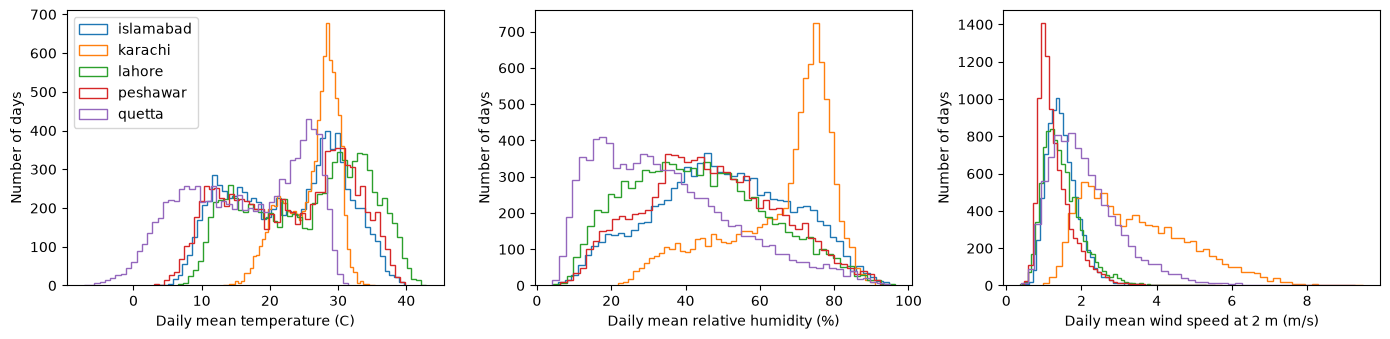

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, (col, label) in zip(axes, [('temperature_2m_mean_c', 'Daily mean temperature (C)'), ('relative_humidity_2m_mean_pct', 'Daily mean relative humidity (%)'), ('wind_speed_2m_mean_m_s', 'Daily mean wind speed at 2 m (m/s)')]):
    for city, g in daily.groupby('city_id'):
        ax.hist(g[col], bins=50, histtype='step', label=city)
    ax.set_xlabel(label); ax.set_ylabel('Number of days')
axes[0].legend(); plt.tight_layout(); plt.show()

**OBSERVATION:** temperature is bimodal-to-wide (strong seasonal cycle); Quetta is cooler and drier. **HYPOTHESIS (untested):** the spread of humidity in Karachi is driven by the monsoon season; this would need a seasonal split to test.

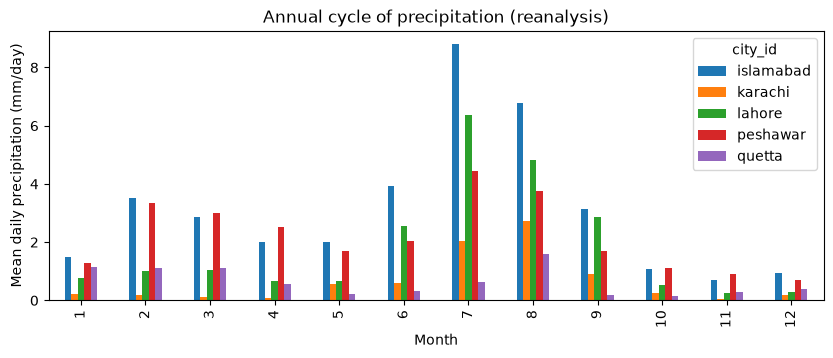

In [5]:
p = daily.assign(m=daily.date.dt.month).groupby(['m', 'city_id']).precipitation_total_mm.mean().unstack()
p.plot(kind='bar', figsize=(10, 3.5)); plt.ylabel('Mean daily precipitation (mm/day)'); plt.xlabel('Month'); plt.title('Annual cycle of precipitation (reanalysis)'); plt.show()

## 3. Temperature seasonal cycle and outliers

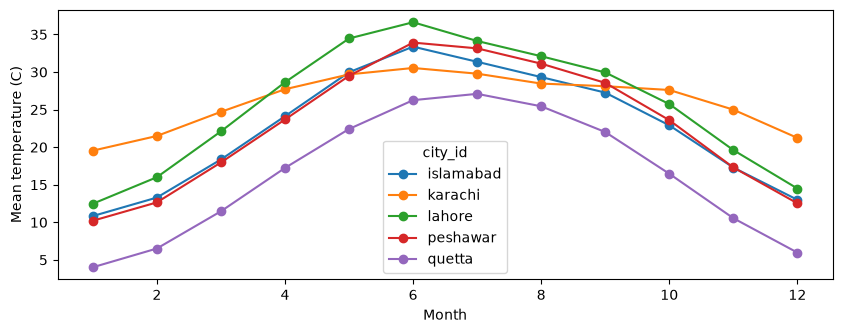

,city_id,date,temperature_2m_max_c
20613,lahore,2007-06-10,50.61
20612,lahore,2007-06-09,50.38
29744,peshawar,2007-06-10,49.86
20614,lahore,2007-06-11,49.71
19146,lahore,2003-06-04,49.61


In [6]:
t = daily.assign(m=daily.date.dt.month).groupby(['m', 'city_id']).temperature_2m_mean_c.mean().unstack()
t.plot(figsize=(10, 3.5), marker='o'); plt.ylabel('Mean temperature (C)'); plt.xlabel('Month'); plt.show()
top = daily.sort_values('temperature_2m_max_c', ascending=False).head(5)[['city_id', 'date', 'temperature_2m_max_c']]
top

**OBSERVATION:** the five highest hourly values are in the table above. They are grid-cell reanalysis values; whether a value is a real heat event or a reanalysis artefact is **not** established here (see the anomaly page in the app, which flags unusual days relative to the training climate only).

In [7]:
print(daily[['temperature_2m_mean_c', 'relative_humidity_2m_mean_pct', 'precipitation_total_mm', 'wind_speed_2m_mean_m_s', 'surface_pressure_mean_kpa']].corr(method='spearman').round(2))

                               temperature_2m_mean_c  \
temperature_2m_mean_c                           1.00   
relative_humidity_2m_mean_pct                   0.07   
precipitation_total_mm                          0.22   
wind_speed_2m_mean_m_s                          0.09   
surface_pressure_mean_kpa                       0.11   

                               relative_humidity_2m_mean_pct  \
temperature_2m_mean_c                                   0.07   
relative_humidity_2m_mean_pct                           1.00   
precipitation_total_mm                                  0.41   
wind_speed_2m_mean_m_s                                  0.21   
surface_pressure_mean_kpa                               0.36   

                               precipitation_total_mm  wind_speed_2m_mean_m_s  \
temperature_2m_mean_c                            0.22                    0.09   
relative_humidity_2m_mean_pct                    0.41                    0.21   
precipitation_total_mm             

**INTERPRETATION:** raw correlations mix the shared seasonal cycle with day-to-day relations; the app's Correlation page removes the seasonal cycle first. Correlation is not causation.